In [1]:
# Ignore warnings - optional
import warnings
warnings.filterwarnings('ignore')

# Import data manipulation libraries
import numpy as np
import pandas as pd
pd.options.plotting.backend = "plotly"

# Import yahoo finance library
import yfinance as yf


References
- YFinance Documentation - https://github.com/ranaroussi/yfinance
- Cufflinks Documentation - https://github.com/santosjorge/cufflinks
- Numpy Documentation - https://numpy.org/doc/stable/
- Pandas Documentation - https://pandas.pydata.org/
- Python Resources - https://github.com/kannansingaravelu/PythonResources
- SQLAlchemy Documentation - https://docs.sqlalchemy.org/en/20/
- SQLite Documentation - https://www.sqlite.org/docs.html

# 2 Data Retrieval
Retrieving EOD, Intraday, Options data

## 2.2 Retrieving end-of-day data for single security
We'll retrieve historical data from yahoo finance using yfinance library


### Example 1

In [2]:
# Fetch the data by specifying the number of period
df1 = yf.download("AAPL", period="10d", progress=False)

# Display the first five rows of the dataframe to check the results. 
df1.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-06-20,213.929993,214.240005,208.850006,209.679993,209.679993,86172500
2024-06-21,210.389999,211.889999,207.110001,207.490005,207.490005,246421400
2024-06-24,207.720001,212.699997,206.589996,208.139999,208.139999,80727000
2024-06-25,209.149994,211.380005,208.610001,209.070007,209.070007,56713900
2024-06-26,211.500000,214.860001,210.639999,213.250000,213.250000,66213200


### Example 2

In [3]:
# Fetch data by specifying the the start and end dates
df2 = yf.download("AAPL", start="2024-06-01", end="2024-06-30", progress=False)

# Display the first five rows of the dataframe to check the results. 
df2.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-06-03,192.899994,194.990005,192.520004,194.029999,194.029999,50080500
2024-06-04,194.639999,195.320007,193.029999,194.350006,194.350006,47471400
2024-06-05,195.399994,196.899994,194.869995,195.869995,195.869995,54156800
2024-06-06,195.690002,196.500000,194.169998,194.479996,194.479996,41181800
2024-06-07,194.649994,196.940002,194.139999,196.889999,196.889999,53103900


In [4]:
# Display last five rows
df2.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-06-24,207.720001,212.699997,206.589996,208.139999,208.139999,80727000
2024-06-25,209.149994,211.380005,208.610001,209.070007,209.070007,56713900
2024-06-26,211.500000,214.860001,210.639999,213.250000,213.250000,66213200
2024-06-27,214.690002,215.740005,212.350006,214.100006,214.100006,49772700
2024-06-28,215.770004,216.070007,210.300003,210.619995,210.619995,82542700


### Example 3

In [5]:
# Fetch data for year to date (YTD)
df3 = yf.download("AAPL", period="ytd", progress=False)

# Display the last five rows of the dataframe to check the results. 
df3.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-06-27,214.690002,215.740005,212.350006,214.100006,214.100006,49772700
2024-06-28,215.770004,216.070007,210.300003,210.619995,210.619995,82542700
2024-07-01,212.089996,217.509995,211.919998,216.750000,216.750000,60402900
2024-07-02,216.149994,220.380005,215.100006,220.270004,220.270004,57960500
2024-07-03,219.960007,221.399994,219.610001,220.290405,220.290405,12807216


## 2.3 Retrieving data for multiple securities|

We'll retrieve historical price data of five stocks from yahoo finance.

In [6]:
# Example 4

# Specify stocks
# https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average
dow_stocks = ['UNH', 'GS', 'HD', 'AMGN', 'MCD']
dow_stocks

['UNH', 'GS', 'HD', 'AMGN', 'MCD']

In [7]:
# Fetch data for multiple stocks at once
df4 = yf.download(dow_stocks, period='ytd', progress=False)['Adj Close']

# Display dataframe
df4.tail()

Ticker,AMGN,GS,HD,MCD,UNH
Date,,,,,
2024-06-27,313.690002,445.959991,341.489990,258.170013,486.440002
2024-06-28,312.450012,452.320007,344.239990,254.839996,509.260010
2024-07-01,311.010010,463.660004,336.190002,249.990005,494.649994
2024-07-02,310.769989,465.609985,334.970001,247.789993,498.239990
2024-07-03,311.000000,468.315002,336.795013,250.149994,490.304993


## 2.3 Retrieving multiple fields for multiple securities
We'll now retrieve multiple fields from yahoo finance.



In [8]:
# Example 5

# Group the stocks
df5 = yf.download(dow_stocks, start="2024-06-01", end="2024-06-30", group_by="ticker", progress=False)


In [9]:
df5.head()

Ticker              GS                                                  \
Price             Open        High         Low       Close   Adj Close   
Date                                                                     
2024-06-03  458.869995  458.869995  450.200012  454.980011  454.980011   
2024-06-04  450.500000  457.709991  449.209991  455.299988  455.299988   
2024-06-05  457.549988  463.019989  457.500000  461.679993  461.679993   
2024-06-06  461.820007  464.519989  457.010010  458.100006  458.100006   
2024-06-07  455.440002  461.160004  454.500000  454.910004  454.910004   

Ticker                     AMGN                                      ...  \
Price        Volume        Open        High         Low       Close  ...   
Date                                                                 ...   
2024-06-03  1930700  306.790009  311.480011  303.850006  307.420013  ...   
2024-06-04  1835000  308.000000  310.920013  307.049988  307.369995  ...   
2024-06-05  1678900  307.799988  310.309998  306.399994  307.380005  ...   
2024-06-06  1598000  306.920013  310.010010  304.309998  305.690002  ...   
2024-06-07  1736100  306.720001  307.959991  304.480011  305.019989  ...   

Ticker              HD                                          MCD  \
Price              Low       Close   Adj Close   Volume        Open   
Date                                                                  
2024-06-03  326.839996  328.010010  328.010010  3712800  257.929993   
2024-06-04  325.100006  328.260010  328.260010  4296800  259.339996   
2024-06-05  325.920013  330.260010  330.260010  2422400  261.500000   
2024-06-06  328.059998  331.100006  331.100006  2979400  260.910004   
2024-06-07  323.929993  327.029999  327.029999  2583800  260.070007   

Ticker                                                               
Price             High         Low       Close   Adj Close   Volume  
Date                                                                 
2024-06-03  259.950012  255.600006  259.750000  259.750000  4342800  
2024-06-04  263.089996  259.250000  262.720001  262.720001  4592700  
2024-06-05  261.739990  258.660004  259.989990  259.989990  4136800  
2024-06-06  261.790009  258.929993  260.720001  260.720001  3354300  
2024-06-07  261.399994  255.339996  256.209991  256.209991  2290100  

[5 rows x 30 columns]

In [10]:
# Display GS stock data
df5['GS']


Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-06-03,458.869995,458.869995,450.200012,454.980011,454.980011,1930700
2024-06-04,450.500000,457.709991,449.209991,455.299988,455.299988,1835000
2024-06-05,457.549988,463.019989,457.500000,461.679993,461.679993,1678900
2024-06-06,461.820007,464.519989,457.010010,458.100006,458.100006,1598000
2024-06-07,455.440002,461.160004,454.500000,454.910004,454.910004,1736100
2024-06-10,452.329987,455.359985,450.299988,453.549988,453.549988,1698600
2024-06-11,451.040009,451.859985,443.380005,444.269989,444.269989,1938200
2024-06-12,455.600006,457.640015,446.190002,448.700012,448.700012,1733000
2024-06-13,446.730011,448.320007,442.149994,446.350006,446.350006,1849100


## Retrieving intraday data

We'll now retrieve intraday data from yahoo finance.


In [11]:
# Example 6

# Retrieve intraday data for last five days
df6 = yf.download('AAPL', period='5d', interval='1m', progress=False)

# Display dataframe
df6

,Open,High,Low,Close,Adj Close,Volume
Datetime,,,,,,
2024-06-27 09:30:00-04:00,214.630005,215.029999,214.259995,214.860001,214.860001,2117691
2024-06-27 09:31:00-04:00,214.830002,215.035004,214.729996,214.820007,214.820007,372113
2024-06-27 09:32:00-04:00,214.789993,215.130005,214.639999,215.050003,215.050003,518338
2024-06-27 09:33:00-04:00,215.032303,215.410004,214.970001,215.160004,215.160004,446512
2024-06-27 09:34:00-04:00,215.160904,215.509995,215.080002,215.100006,215.100006,419420
...,...,...,...,...,...,...
2024-07-03 10:15:00-04:00,220.139999,220.429993,220.080002,220.320007,220.320007,280613
2024-07-03 10:16:00-04:00,220.285004,220.339996,220.055801,220.160004,220.160004,133983
2024-07-03 10:17:00-04:00,220.160004,220.255005,220.040100,220.149994,220.149994,167834


## Retrieving option chain

We'll now retrieve option chain for SPY for March 2024 expiration from yahoo finance and filter the output to display the first seven columns.

In [12]:
# Example 7

# Ticker object
spy = yf.Ticker('SPY')

In [13]:
spy.options

# https://uk.finance.yahoo.com/quote/SPY/options/

('2024-07-03',
 '2024-07-05',
 '2024-07-08',
 '2024-07-09',
 '2024-07-10',
 '2024-07-11',
 '2024-07-12',
 '2024-07-19',
 '2024-07-26',
 '2024-07-31',
 '2024-08-02',
 '2024-08-09',
 '2024-08-16',
 '2024-08-30',
 '2024-09-20',
 '2024-09-30',
 '2024-10-18',
 '2024-10-31',
 '2024-11-15',
 '2024-11-29',
 '2024-12-20',
 '2024-12-31',
 '2025-01-17',
 '2025-01-31',
 '2025-03-21',
 '2025-03-31',
 '2025-04-17',
 '2025-06-20',
 '2025-06-30',
 '2025-09-19',
 '2025-12-19',
 '2026-01-16',
 '2026-06-18',
 '2026-12-18')

In [14]:
# Get SPY option chain for March 28th expiration
# https://finance.yahoo.com/quote/SPY240930C00545000
options = spy.option_chain('2024-09-30')
options

Options(calls=         contractSymbol             lastTradeDate  strike  lastPrice     bid  \
0    SPY240930C00300000 2024-06-24 17:46:42+00:00   300.0     248.59  252.46   
1    SPY240930C00305000 2024-06-18 17:37:53+00:00   305.0     246.47  247.52   
2    SPY240930C00310000 2024-06-21 13:47:49+00:00   310.0     238.47  242.60   
3    SPY240930C00315000 2024-06-18 18:38:41+00:00   315.0     236.02  237.63   
4    SPY240930C00320000 2024-06-18 16:16:22+00:00   320.0     231.22  232.98   
..                  ...                       ...     ...        ...     ...   
187  SPY240930C00635000 2024-07-01 16:01:08+00:00   635.0       0.09    0.09   
188  SPY240930C00640000 2024-07-01 13:30:00+00:00   640.0       0.09    0.08   
189  SPY240930C00645000 2024-07-01 19:55:04+00:00   645.0       0.07    0.07   
190  SPY240930C00650000 2024-07-02 16:07:55+00:00   650.0       0.06    0.06   
191  SPY240930C00655000 2024-07-02 19:05:43+00:00   655.0       0.06    0.06   

        ask  change  perc

In [15]:
# Filter calls for strike above 545
df7 = options.calls[(options.calls['strike']>540) & (options.calls['strike']<550)]

# Check the filtered output
df7.iloc[:,:7]

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change
134,SPY240930C00541000,2024-07-02 18:50:19+00:00,541.0,21.00,21.88,21.97,0.000000
135,SPY240930C00542000,2024-07-02 14:57:51+00:00,542.0,18.83,21.13,21.21,0.000000
136,SPY240930C00543000,2024-07-02 19:58:01+00:00,543.0,20.02,20.39,20.46,0.000000
137,SPY240930C00544000,2024-07-02 18:06:00+00:00,544.0,18.37,19.59,19.65,0.000000
138,SPY240930C00545000,2024-07-03 14:00:33+00:00,545.0,18.65,18.89,18.95,0.779999
139,SPY240930C00546000,2024-07-03 13:44:45+00:00,546.0,18.05,18.06,18.61,0.389999
140,SPY240930C00547000,2024-07-03 13:53:31+00:00,547.0,17.43,17.49,17.56,0.430000
141,SPY240930C00548000,2024-07-03 13:39:37+00:00,548.0,16.80,16.92,16.98,0.330000
142,SPY240930C00549000,2024-07-03 13:57:10+00:00,549.0,16.25,16.16,16.22,0.470000


## Retrieving Hypertext Markup Language (HTML)
We'll now retrieve India's benchmark index NIFTY50 Index data from Wikipedia.

In [16]:
# Example 8

pd.read_html('https://en.wikipedia.org/wiki/NIFTY_50')[1]

Category All-time highs[12]                        
   Category              Value                    Date
0   Closing           24286.50  Wednesday, 3 July 2024
1  Intraday           24309.15  Wednesday, 3 July 2024

In [17]:
# Read data from wikipedia
nifty50 = pd.read_html('https://en.wikipedia.org/wiki/NIFTY_50')[2].Symbol.to_list()

# Read five symbols
nifty50[:5]

['ADANIENT', 'ADANIPORTS', 'APOLLOHOSP', 'ASIANPAINT', 'AXISBANK']

In [18]:
yf.download([f"{x}.NS" for x in nifty50[:5]], start="2024-06-01", end="2024-06-30", group_by="ticker", progress=False)

Ticker      AXISBANK.NS                                                      \
Price              Open         High          Low        Close    Adj Close   
Date                                                                          
2024-06-03  1197.050049  1242.199951  1193.400024  1223.900024  1223.900024   
2024-06-04  1224.000000  1224.000000  1101.550049  1131.250000  1131.250000   
2024-06-05  1138.000000  1193.000000  1110.699951  1184.500000  1184.500000   
2024-06-06  1192.099976  1195.900024  1163.250000  1170.949951  1170.949951   
2024-06-07  1178.000000  1195.199951  1166.750000  1186.800049  1186.800049   
2024-06-10  1185.000000  1212.400024  1185.000000  1200.000000  1200.000000   
2024-06-11  1204.449951  1209.349976  1190.449951  1194.599976  1194.599976   
2024-06-12  1192.099976  1206.150024  1184.099976  1187.900024  1187.900024   
2024-06-13  1201.800049  1202.000000  1173.449951  1174.650024  1174.650024   
2024-06-14  1180.949951  1184.650024  1170.000000  1181.050049  1181.050049   
2024-06-18  1194.000000  1194.000000  1181.150024  1191.900024  1191.900024   
2024-06-19  1193.000000  1243.349976  1185.500000  1226.650024  1226.650024   
2024-06-20  1230.099976  1241.500000  1220.400024  1239.500000  1239.500000   
2024-06-21  1246.000000  1246.000000  1223.750000  1237.449951  1237.449951   
2024-06-24  1231.000000  1235.750000  1225.050049  1228.099976  1228.099976   
2024-06-25  1234.449951  1278.750000  1226.000000  1271.449951  1271.449951   
2024-06-26  1281.099976  1292.949951  1259.199951  1285.400024  1285.400024   
2024-06-27  1310.000000  1310.000000  1280.000000  1288.949951  1288.949951   
2024-06-28  1283.099976  1289.900024  1261.599976  1265.250000  1265.250000   

Ticker                ADANIENT.NS                                         ...  \
Price         Volume         Open         High          Low        Close  ...   
Date                                                                      ...   
2024-06-03  22197339  3725.000000  3743.899902  3586.050049  3645.250000  ...   
2024-06-04  24135989  3520.000000  3520.000000  2733.949951  2941.250000  ...   
2024-06-05  21039499  3030.000000  3150.000000  2750.000000  3115.350098  ...   
2024-06-06  12006879  3184.000000  3222.399902  3137.149902  3185.649902  ...   
2024-06-07   8583998  3170.399902  3233.750000  3151.600098  3219.550049  ...   
2024-06-10   9995057  3267.000000  3284.399902  3205.500000  3220.100098  ...   
2024-06-11   9390212  3224.000000  3265.000000  3195.050049  3221.250000  ...   
2024-06-12   7199718  3224.899902  3245.000000  3208.000000  3219.050049  ...   
2024-06-13   5321148  3230.000000  3254.000000  3207.250000  3224.800049  ...   
2024-06-14   4451031  3225.000000  3275.000000  3221.100098  3261.750000  ...   
2024-06-18   6837181  3310.000000  3345.000000  3287.199951  3309.050049  ...   
2024-06-19  17987437  3314.000000  3314.000000  3226.300049  3261.899902  ...   
2024-06-20   8206858  3263.899902  3315.000000  3240.000000  3259.449951  ...   
2024-06-21  29311314  3265.050049  3277.100098  3176.399902  3189.300049  ...   
2024-06-24   6676530  3185.750000  3214.800049  3135.000000  3194.600098  ...   
2024-06-25  17607952  3204.750000  3208.449951  3156.350098  3171.100098  ...   
2024-06-26  13956370  3169.050049  3187.699951  3163.899902  3170.500000  ...   
2024-06-27  22311393  3177.000000  3202.250000  3150.000000  3175.149902  ...   
2024-06-28   7167069  3190.000000  3211.949951  3157.000000  3177.149902  ...   

Ticker     ASIANPAINT.NS                                    ADANIPORTS.NS  \
Price                Low        Close    Adj Close   Volume          Open   
Date                                                                        
2024-06-03   2860.050049  2866.449951  2838.981201   952701   1549.000000   
2024-06-04   2775.750000  2857.649902  2830.265625  2683847   1558.000000   
2024-06-05   2864.500000  2961.750000  2933.368164  2410576   1281.000000   
2024-06-06   288

# Database Storage & Retrieval

Let's store the data in the database and load back for manipulation.

## Storing Nifty50 data in SQLite Database

In [19]:
# %load_ext autoreload
# %autoreload 1

In [20]:
# Import & create database 
# https://sqlite.org/cli.html
from sqlalchemy import create_engine, text
engine = create_engine('sqlite:///India')

In [21]:
# Fetch data from yahoo using list comprehension
data = [yf.download(symbol+'.NS', period='250d', progress=False).reset_index() for symbol in nifty50] 

In [22]:
# save it to database
for frame, symbol in zip(data, nifty50):
    frame.to_sql(symbol, engine, if_exists='replace', index=False)

# Data Manipulation
Next, we'll see some methods used in data wrangling. This is critical if you work on financial data or time series.

## Filter & Query Methods
We'll now see some examples of subset selection using Panda's filter and query methods.

In [23]:
# Query from database
query = 'SELECT * FROM  "TITAN"'
with engine.connect() as connection:
    df = pd.read_sql_query(text(query), connection)

# Convert the date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set the date column as the DataFrame index
df.set_index('Date', inplace=True)

In [24]:
# Get first few days of data
df.first('3D')

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-06-26,2940.0,2981.000000,2940.000000,2972.600098,2953.336670,839713
2023-06-27,2973.0,2989.199951,2940.699951,2975.699951,2956.416260,913730
2023-06-28,2995.0,3044.399902,2985.050049,3028.100098,3008.477051,1525117


In [25]:
# Get last few days of data
df.last('3D')

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-07-01,3382.000000,3435.000000,3381.500000,3431.449951,3431.449951,1001832
2024-07-02,3446.000000,3450.000000,3385.300049,3399.649902,3399.649902,878947
2024-07-03,3420.800049,3426.949951,3341.899902,3360.250000,3360.250000,979744


In [26]:
# Filter based on column
df.filter(['Close']).last("3D")

,Close
Date,
2024-07-01,3431.449951
2024-07-02,3399.649902
2024-07-03,3360.250000


In [27]:
# Filter based on row or index
df.filter(like="2024-06-24", axis=0)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-06-24,3380.350098,3429.0,3372.300049,3412.350098,3401.220947,645002


In [28]:
# Query for a specific condition. Ex: Close price > 3800
df.query('Close>3800')

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-01-16,3758.850098,3858.000000,3756.000000,3820.300049,3807.840332,1170685
2024-01-17,3818.949951,3855.000000,3800.000000,3830.050049,3817.558594,723356
2024-01-19,3742.199951,3861.500000,3740.699951,3810.600098,3798.172119,2566367
2024-01-29,3760.600098,3875.000000,3760.550049,3866.649902,3854.039062,699215
2024-03-06,3748.050049,3815.000000,3702.699951,3810.750000,3798.321533,765602
2024-03-28,3760.000000,3838.300049,3732.550049,3801.800049,3789.400635,1590738


In [29]:
# Query for condition where the difference between High and Low is greater than 150
df.query('High-Low>150')

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-01-23,3786.000000,3858.000000,3705.750000,3739.649902,3727.453125,1053510
2024-01-30,3882.000000,3886.949951,3715.000000,3735.750000,3723.566162,852445
2024-03-13,3759.000000,3762.000000,3590.000000,3625.699951,3613.875000,1027729
2024-04-18,3645.899902,3660.000000,3501.000000,3525.100098,3513.603271,1677946
2024-05-06,3476.000000,3488.800049,3257.000000,3280.149902,3269.451904,6891728
2024-06-04,3261.199951,3295.199951,3055.649902,3238.949951,3228.386230,2934800
2024-06-07,3294.399902,3456.600098,3294.399902,3444.050049,3432.817383,2084099


In [30]:
# Query for a multiple conditions. Ex: Close > 3700 and High-Low > 150
df.query('Close>3700 & High-Low>150')

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-01-23,3786.0,3858.000000,3705.75,3739.649902,3727.453125,1053510
2024-01-30,3882.0,3886.949951,3715.00,3735.750000,3723.566162,852445


In [31]:
# Query for condition where Close>Open price
df.query('Close>Open')

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-06-26,2940.000000,2981.000000,2940.000000,2972.600098,2953.336670,839713
2023-06-27,2973.000000,2989.199951,2940.699951,2975.699951,2956.416260,913730
2023-06-28,2995.000000,3044.399902,2985.050049,3028.100098,3008.477051,1525117
2023-06-30,3046.000000,3067.949951,3029.149902,3047.649902,3027.899902,946112
2023-07-04,3041.500000,3090.000000,3039.000000,3074.649902,3054.725098,1291238
...,...,...,...,...,...,...
2024-06-18,3554.800049,3625.000000,3538.000000,3589.000000,3577.294678,1585048
2024-06-24,3380.350098,3429.000000,3372.300049,3412.350098,3401.220947,645002
2024-06-27,3370.000000,3392.500000,3361.050049,3380.600098,3380.600098,1462935


In [32]:
# Query for condition where Open price is equal to Low price of the day
df.query('Open==Low')

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-06-26,2940.000000,2981.000000,2940.000000,2972.600098,2953.336670,839713
2023-07-31,2950.000000,3017.949951,2950.000000,3004.050049,2994.252441,656048
2023-09-13,3178.050049,3270.000000,3178.050049,3263.199951,3252.557129,1370306
2023-12-08,3575.000000,3646.949951,3575.000000,3634.649902,3622.795654,1562141
2024-03-26,3665.000000,3729.949951,3665.000000,3698.199951,3686.138428,1158224
2024-05-14,3250.000000,3308.000000,3250.000000,3288.899902,3278.173340,620163
2024-06-07,3294.399902,3456.600098,3294.399902,3444.050049,3432.817383,2084099


## Resampling data
We'll now resample the frequency of time series.

In [33]:
# https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
# Resampling to derive weekly values from daily time series
df_weekly = df.resample('W').last()

# Display the last five rows of the data frame to check the output
df_weekly.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-06-09,3294.399902,3456.600098,3294.399902,3444.050049,3432.817383,2084099
2024-06-16,3490.000000,3535.000000,3479.000000,3530.050049,3518.536865,2346892
2024-06-23,3430.699951,3473.649902,3383.399902,3399.750000,3388.661865,2707405
2024-06-30,3380.600098,3419.899902,3366.350098,3404.199951,3404.199951,1005498
2024-07-07,3420.800049,3426.949951,3341.899902,3360.250000,3360.250000,979744


In [34]:
# Resampling to a specific day of the week: Thu
df_weekly_thu = df.resample('W-THU').last()

In [35]:
# Display the last five rows of the data frame to check the output
df_weekly_thu.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-06-06,3329.000000,3360.000000,3290.750000,3321.649902,3310.816406,1825503
2024-06-13,3424.949951,3477.100098,3390.000000,3472.199951,3460.875488,1753028
2024-06-20,3474.000000,3490.000000,3418.100098,3435.949951,3424.743896,2377432
2024-06-27,3370.000000,3392.500000,3361.050049,3380.600098,3380.600098,1462935
2024-07-04,3420.800049,3426.949951,3341.899902,3360.250000,3360.250000,979744


In [36]:
# Resampling to derive monthly values from daily time series
df_monthly = df.resample('M').last()

# Display the last five rows of the data frame to check the output
df_monthly.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-03-31,3760.000000,3838.300049,3732.550049,3801.800049,3789.400635,1590738
2024-04-30,3602.649902,3619.500000,3580.000000,3589.250000,3577.543945,963220
2024-05-31,3298.000000,3328.800049,3216.750000,3241.899902,3231.326660,2524214
2024-06-30,3380.600098,3419.899902,3366.350098,3404.199951,3404.199951,1005498
2024-07-31,3420.800049,3426.949951,3341.899902,3360.250000,3360.250000,979744


# Interactive Visualization of Time Series
We use cufflinks for interactive visualization. It is one of the most feature rich third-party wrapper around Plotly by Santos Jorge. It binds the power of plotly with the flexibility of pandas for easy plotting.

When you import cufflinks library, all pandas data frames and series objects have a new method .iplot() attached to them which is similar to pandas' built-in .plot() method.


In [37]:
# Import cufflinks for visualization
import cufflinks as cf
cf.set_config_file(offline=True)

## Plotting Line Chart
Next, we'll plot the time series data in the line format.

In [38]:
df['Close'].iplot(kind='line', title='Line Chart')

## Plotting OHLC Data
Next, we'll plot the time series data in ohlc format.

In [39]:
df[-30:].iplot(kind='ohlc', title='Bar Chart')

## Plotting Candlestick
Next, we'll plot an interactive candlestick chart.

In [40]:
df[-30:].iplot(kind='candle', title='Candle Chart')

## Plotting Selected Stocks
Next, we'll compare the GS & HD data that we fetched from Yahoo Finance.

In [41]:
# Use secondary axis
df4[['GS', 'HD']].iplot(secondary_y='HD')

## Plotting using Subplots

In [42]:
# Use subplots
df4[['GS', 'HD']].iplot(subplots=True)

## Normalized Plot

In [43]:
# Normalize plot
df4.normalize().iplot()

## Visualising Return Series
We'll now plot historical daily log normal return series using just one line of code.

In [44]:
# Calculating Log Normal Returns
# Use numpy log function to derive log normal returns
daily_returns = np.log(df4).diff().dropna()

# Display the last five rows of the data frame to check the output
daily_returns.head()

Ticker,AMGN,GS,HD,MCD,UNH
Date,,,,,
2024-01-03,0.011035,-0.016907,-0.019961,-0.008961,0.004975
2024-01-04,0.008214,0.003034,0.000975,-0.009043,0.006235
2024-01-05,-0.000561,0.009072,0.012766,-0.009471,-0.014851
2024-01-08,0.025674,0.006243,0.014446,0.010019,-0.001602
2024-01-09,-0.011713,-0.013254,-0.005013,-0.003535,0.003442


## Plotting Annual Returns

In [45]:
# Plot Mean Annual Returns
(daily_returns.mean()*252*100).iplot(kind='bar')

# Plotting Annualized Volatility

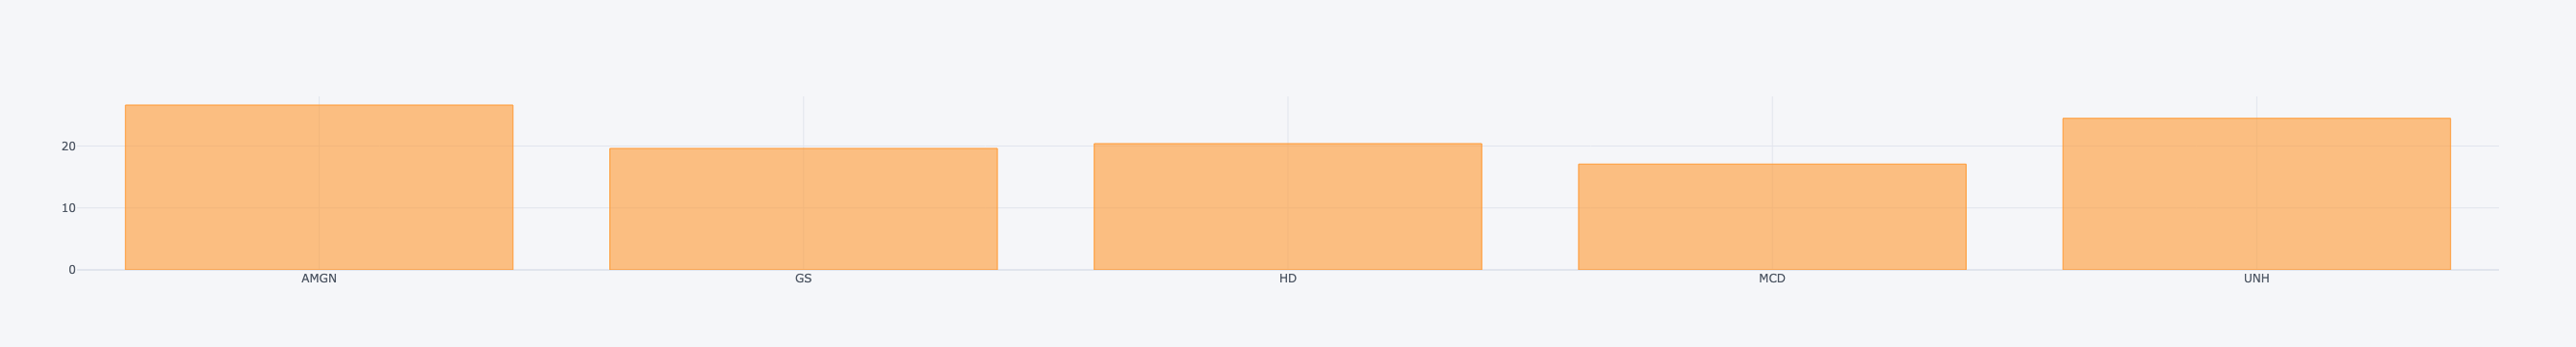

In [46]:
# Plot Mean Annualized Volatility
(daily_returns.std()*np.sqrt(252)*100).iplot(kind='bar')

# Plotting Rolling Returns

In [47]:
# To calculate 5 days rolling returns, simply sum daily returns for 5 days as log returns are additive
rolling_return = daily_returns.rolling(5).sum().dropna()

# Display the last five rows of the data frame to check the output
rolling_return.head()

Ticker,AMGN,GS,HD,MCD,UNH
Date,,,,,
2024-01-09,0.032650,-0.011813,0.003212,-0.020990,-0.001800
2024-01-10,0.012821,0.000445,0.053361,-0.001020,-0.008132
2024-01-11,-0.000231,-0.008391,0.051628,0.008227,-0.010580
2024-01-12,0.011518,-0.022744,0.036560,0.015383,-0.029977
2024-01-16,-0.024091,-0.021865,0.029732,-0.002779,-0.032911


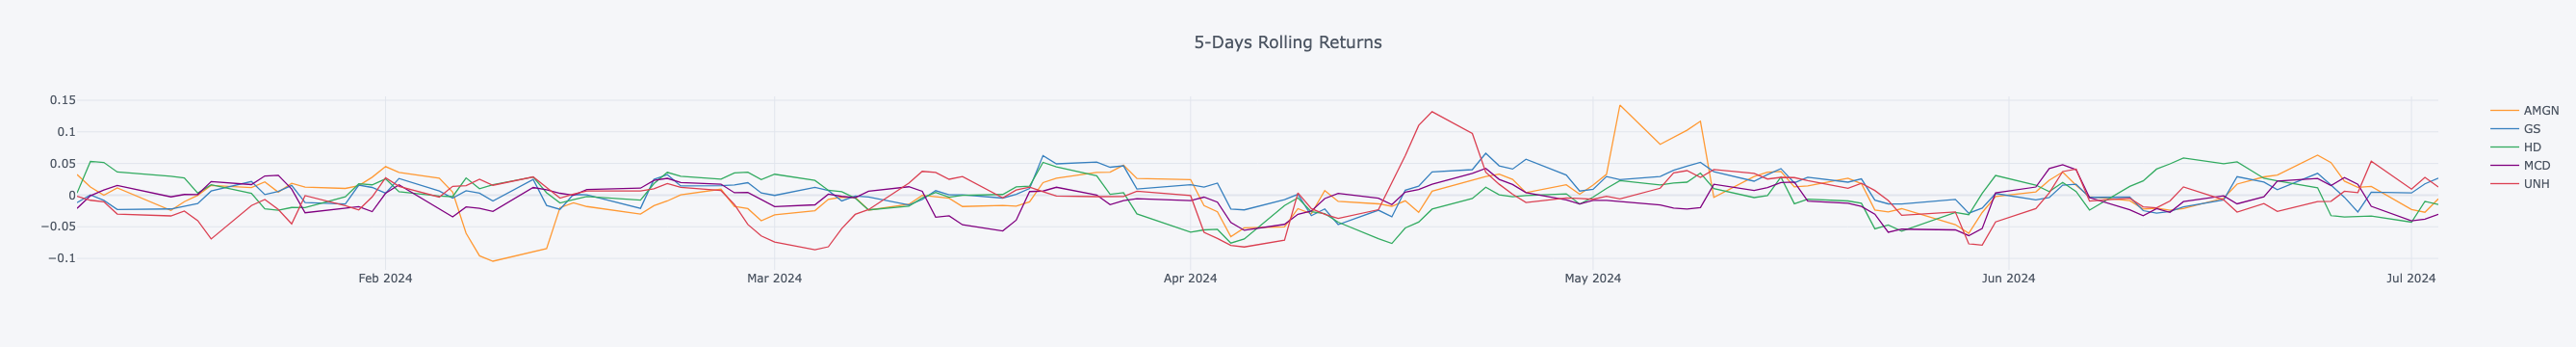

In [48]:
# Plot Rolling Returns
rolling_return.iplot(title='5-Days Rolling Returns')

## Time Series Statistics
Statistics is a branch of mathematics that deals with collecting, interpreting, organization and interpretation of data. The two main categories of statistics are descriptive statistics and inferential statistics.

Descriptive statistics help us to understand the data in a meaningful way and is an important part of data analysis. While inferential statistics allows us to infer trends and derive conclusion from it.

In [49]:
# Analysing the daily returns data
daily_returns.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AMGN,126.0,0.000473,0.016758,-0.066044,-0.007116,-0.000389,0.006836,0.111702
GS,126.0,0.001591,0.012349,-0.036017,-0.005792,0.000270,0.009768,0.042565
HD,126.0,-0.000091,0.012838,-0.041436,-0.008373,-0.000288,0.008445,0.030188
MCD,126.0,-0.001267,0.010758,-0.039682,-0.007838,-0.000894,0.004819,0.026697
UNH,126.0,-0.000692,0.015408,-0.066618,-0.008677,0.000490,0.007181,0.050879


## Log Normal Distribution
A normal distribution is the most common and widely used distribution in statistics. It is popularly referred as a “bell curve” or “Gaussian curve”. Financial time series though random in short term, follows a log normal distribution on a longer time frame.

Now that we have derived the daily log returns, we will plot this return distribution and check whether the stock returns follows log normality.

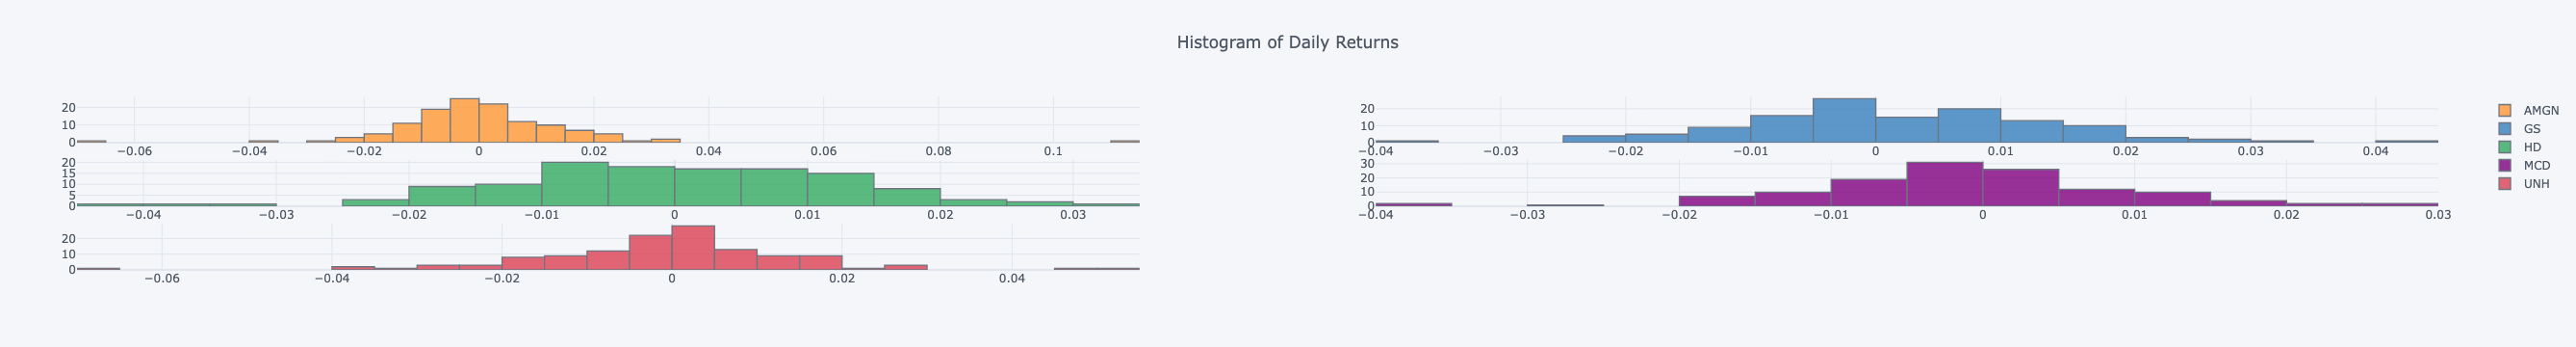

In [50]:
# Plot log normal distribution of returns
daily_returns.iplot(kind='histogram', title = 'Histogram of Daily Returns', subplots=True)

## Correlation
Correlation defines the similarity between two random variables. As an example we will check correlation between our Nasdaq listed stocks.

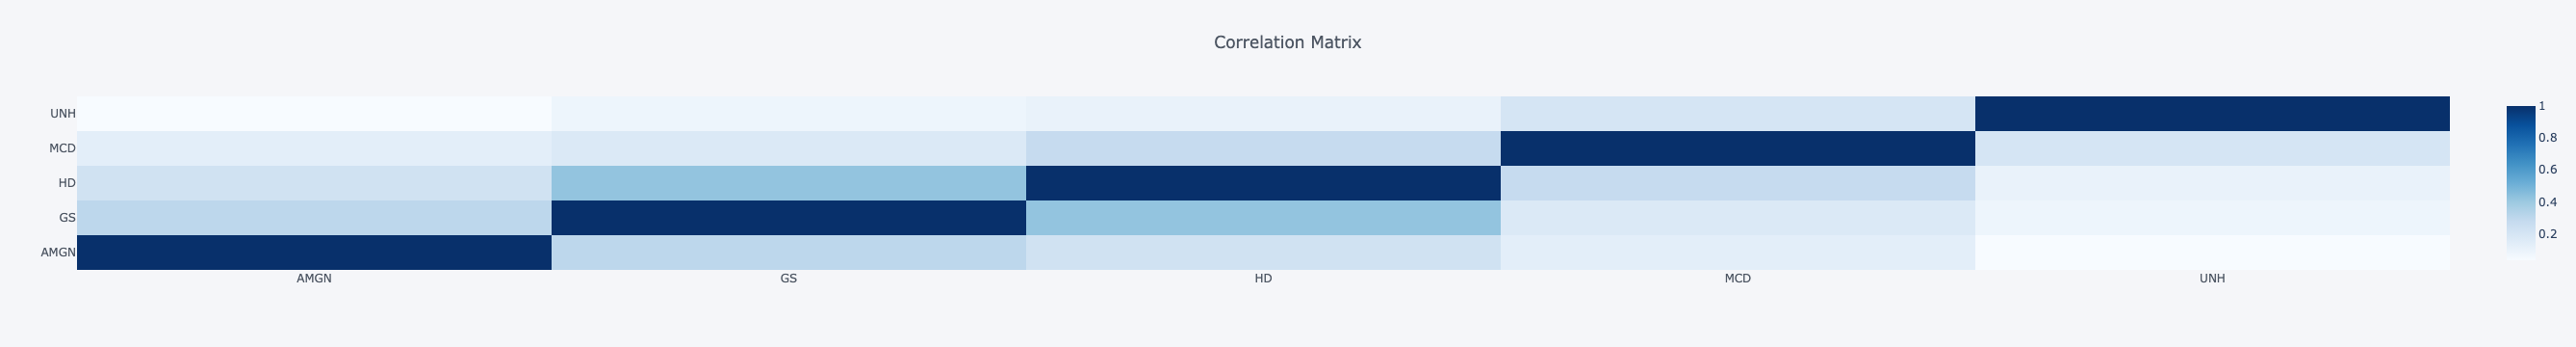

In [52]:
# Plot correlation of returns
daily_returns.corr().iplot(kind='heatmap', title="Correlation Matrix", colorscale="Blues")